<a href="https://colab.research.google.com/github/RobJavVar/DataSciencePsychNeuro/blob/master/ExerciseSubmissions/16_selecting-the-best-model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 16: Model selection

This homework is designed to give you practice implementing model selection techniques, including best subset selection and forward/backward stepwise selection.

You won't need to load in any data for this homework, we will be simulating our own.

---
## 1. Best subset selection (4 points)

In this question, we will first generate simulated data, and then use it to perform best subset selection.

a) Use `rnorm()` to generate a dataset including a predictor $X$ of length $n = 100$ and a noise vector $\epsilon$ of length $n = 100$. Generate data for a response variable $Y$ of length $n = 100$ according to the model

$Y = \beta_0 + \beta_1X + \beta_2X^2 + \beta_3X^3 + \epsilon$

where $\beta_0$, $\beta_1$, $\beta_2$, and $\beta_3$ are constants of your choice.


In [3]:
x<- rnorm(100)
epsilon_noise <- rnorm(100, mean = , sd = 1)

beta_0 <- 1
beta_1 <- 2
beta_2 <- 3
beta_3 <- 0.5
set.seed(15)

In [5]:
y <- beta_0 + beta_1*x + beta_2*x^2 + beta_3*x^3 + epsilon_noise 

In [7]:
data <- data.frame(y=y, x=x)

b) Use `regsubsets()` to perform best subset selection to determine the best model that contains the predictor variables $X$, $X^2$, . . . , $X^{10}$. Print the model summary.

In [9]:
install.packages("leaps")

Installing package into 'C:/Users/luzsa/AppData/Local/R/win-library/4.5'
(as 'lib' is unspecified)



package 'leaps' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\luzsa\AppData\Local\Temp\RtmpCoLoor\downloaded_packages


In [10]:
library(leaps)

Warning message:
"package 'leaps' was built under R version 4.5.3"


In [12]:
#regfit prep
#adding polynomials
data$x2  <- x^2
data$x3  <- x^3
data$x4  <- x^4
data$x5  <- x^5
data$x6  <- x^6
data$x7  <- x^7
data$x8  <- x^8
data$x9  <- x^9
data$x10 <- x^10

In [13]:
#regfit use
regfit <- regsubsets(y ~ ., data = data, nvmax = 10)

#summary
reg_summary <- summary(regfit)
reg_summary

Subset selection object
Call: regsubsets.formula(y ~ ., data = data, nvmax = 10)
10 Variables  (and intercept)
    Forced in Forced out
x       FALSE      FALSE
x2      FALSE      FALSE
x3      FALSE      FALSE
x4      FALSE      FALSE
x5      FALSE      FALSE
x6      FALSE      FALSE
x7      FALSE      FALSE
x8      FALSE      FALSE
x9      FALSE      FALSE
x10     FALSE      FALSE
1 subsets of each size up to 10
Selection Algorithm: exhaustive
          x   x2  x3  x4  x5  x6  x7  x8  x9  x10
1  ( 1 )  " " " " "*" " " " " " " " " " " " " " "
2  ( 1 )  " " "*" "*" " " " " " " " " " " " " " "
3  ( 1 )  "*" "*" "*" " " " " " " " " " " " " " "
4  ( 1 )  "*" "*" "*" " " " " " " " " " " "*" " "
5  ( 1 )  "*" "*" "*" " " "*" " " "*" " " " " " "
6  ( 1 )  "*" "*" "*" " " "*" " " "*" " " " " "*"
7  ( 1 )  "*" "*" "*" " " " " "*" "*" " " "*" "*"
8  ( 1 )  "*" "*" "*" " " " " "*" "*" "*" "*" "*"
9  ( 1 )  "*" "*" "*" "*" " " "*" "*" "*" "*" "*"
10  ( 1 ) "*" "*" "*" "*" "*" "*" "*" "*" "*" "*"

c) Plot the Mallows' Cp, Bayesian Information Criteria (BIC) and the adjusted coefficient of determination, $R^2$, for each model tested. Which is the best model? Report the coefficients of the best model.

Cp: 4BIC: 3r2: 4

(Intercept)           x          x2          x3 
  1.2648354   1.7509730   2.7996078   0.5719495

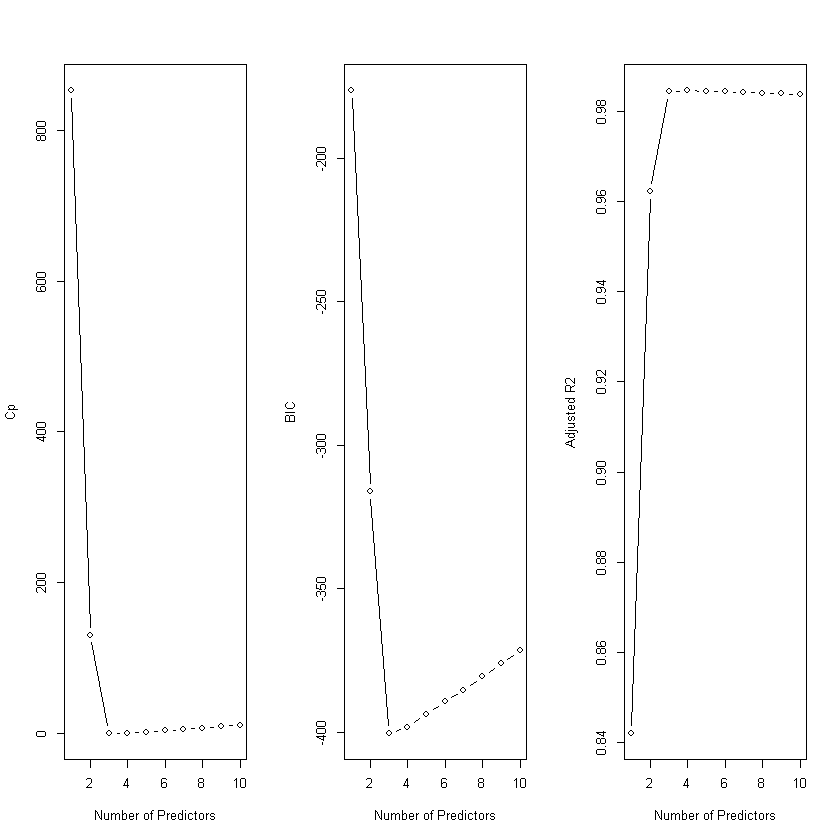

In [22]:
par(mfrow = c(1, 3))  # plot side by side

#Cp
plot(reg_summary$cp, xlab = "Number of Predictors", ylab = "Cp", type = "b")
points(which.min(reg_summary$cp), reg_summary$cp[which.min(reg_summary$cp)])

# BIC
plot(reg_summary$bic, xlab = "Number of Predictors", ylab = "BIC", type = "b")
points(which.min(reg_summary$bic), reg_summary$bic[which.min(reg_summary$bic)])

#r2
plot(reg_summary$adjr2, xlab = "Number of Predictors", ylab = "Adjusted R2", type = "b")
points(which.max(reg_summary$adjr2), reg_summary$adjr2[which.max(reg_summary$adjr2)])

# Print best model size for each criterion
cat("Cp:", which.min(reg_summary$cp)) #4
cat("BIC:", which.min(reg_summary$bic)) #3
cat("r2:", which.max(reg_summary$adjr2)) #4

#coef
best_model <- which.min(reg_summary$bic)
coef(regfit, best_model)

> The 3 criteria of CP, BIC, and adjusted R-squared showed x, x2, and x3 as the best predictors. Cp had 4 predictors, BIC had 3 predictors, adjusted R-squared had 4 predictors but amongst these the BIC seems be the most accurate with its uptic for number of predictors.

---
## 2. Forward and backwards stepwise selection (3 points)

Using the same simulated data from question 1, use forward stepwise selection, and backwards stepwise selections to determine the best model. Again, for both model selection methods, plot the Mallows' Cp, Bayesian Information Criteria (BIC) and the adjusted coefficient of determination, $R^2$, for each model tested. Report the coefficients of the best model.

a) Forward stepwise selection:

In [24]:

# Forward stepwise
regfit_fwd <- regsubsets(y ~ ., data = data, nvmax = 10, method = "forward")
fwd_summary <- summary(regfit_fwd)

# Backward stepwise
regfit_bwd <- regsubsets(y ~ ., data = data, nvmax = 10, method = "backward")
bwd_summary <- summary(regfit_bwd)




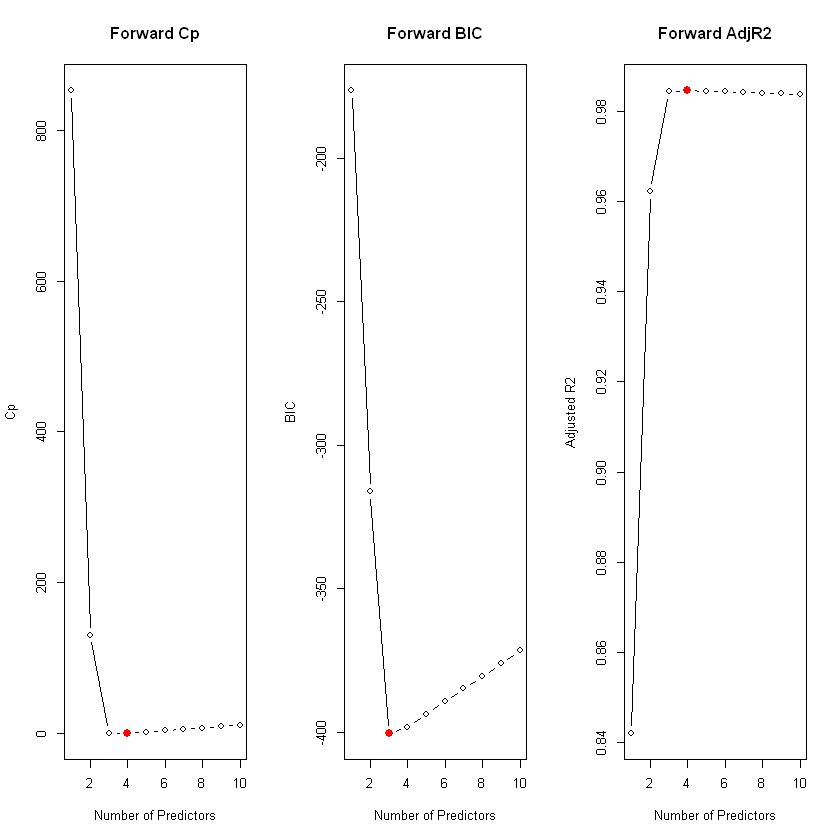

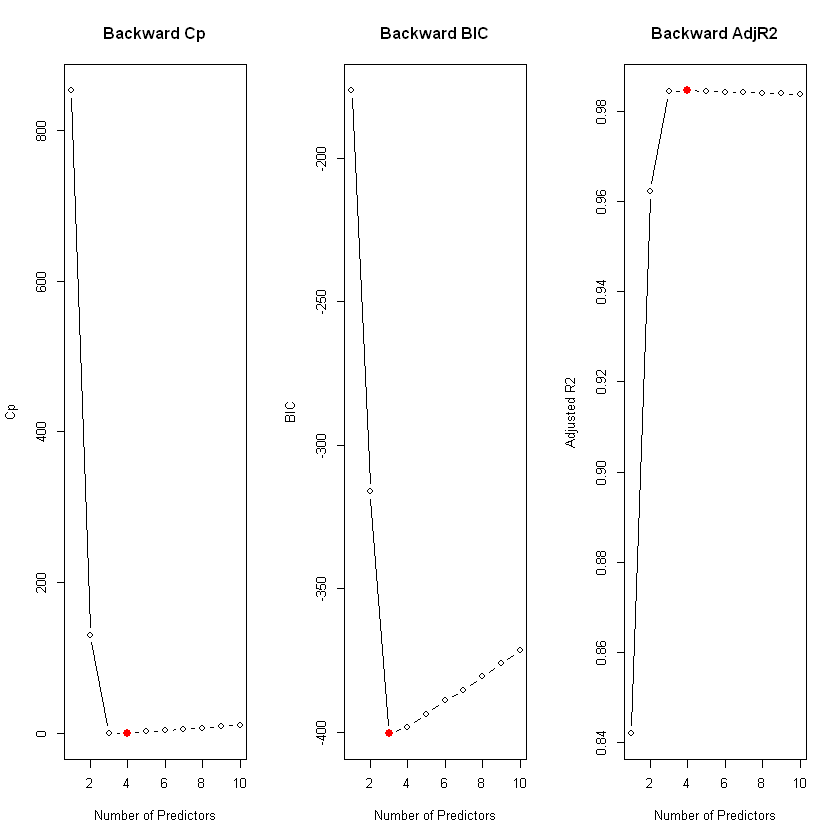

In [25]:
# Plot forward
par(mfrow = c(1, 3))
plot(fwd_summary$cp,    xlab = "Number of Predictors", ylab = "Cp",          type = "b", main = "Forward Cp")
points(which.min(fwd_summary$cp), fwd_summary$cp[which.min(fwd_summary$cp)], col = "red", pch = 20, cex = 2)
plot(fwd_summary$bic,   xlab = "Number of Predictors", ylab = "BIC",         type = "b", main = "Forward BIC")
points(which.min(fwd_summary$bic), fwd_summary$bic[which.min(fwd_summary$bic)], col = "red", pch = 20, cex = 2)
plot(fwd_summary$adjr2, xlab = "Number of Predictors", ylab = "Adjusted R2", type = "b", main = "Forward AdjR2")
points(which.max(fwd_summary$adjr2), fwd_summary$adjr2[which.max(fwd_summary$adjr2)], col = "red", pch = 20, cex = 2)

# Plot backward
par(mfrow = c(1, 3))
plot(bwd_summary$cp,    xlab = "Number of Predictors", ylab = "Cp",          type = "b", main = "Backward Cp")
points(which.min(bwd_summary$cp), bwd_summary$cp[which.min(bwd_summary$cp)], col = "red", pch = 20, cex = 2)
plot(bwd_summary$bic,   xlab = "Number of Predictors", ylab = "BIC",         type = "b", main = "Backward BIC")
points(which.min(bwd_summary$bic), bwd_summary$bic[which.min(bwd_summary$bic)], col = "red", pch = 20, cex = 2)
plot(bwd_summary$adjr2, xlab = "Number of Predictors", ylab = "Adjusted R2", type = "b", main = "Backward AdjR2")
points(which.max(bwd_summary$adjr2), bwd_summary$adjr2[which.max(bwd_summary$adjr2)], col = "red", pch = 20, cex = 2)


In [26]:
# Best model coefs
cat("Forward best by BIC:", which.min(fwd_summary$bic), "predictors\n")
coef(regfit_fwd, which.min(fwd_summary$bic))

cat("Backward best by BIC:", which.min(bwd_summary$bic), "predictors\n")
coef(regfit_bwd, which.min(bwd_summary$bic))


Forward best by BIC: 3 predictors


(Intercept)           x          x2          x3 
  1.2648354   1.7509730   2.7996078   0.5719495

Backward best by BIC: 3 predictors


(Intercept)           x          x2          x3 
  1.2648354   1.7509730   2.7996078   0.5719495

Forward best by BIC: 3 predictors
(Intercept)1.26483536437986x1.7509730262695x22.79960776994296x30.571949455453324
Backward best by BIC: 3 predictors
(Intercept)1.26483536437986x1.7509730262695x22.79960776994296x30.571949455453324


c) Compare your results from parts a and b with those of question 1.

>All three methods lected the same 3-predictor model using BIC, with identical coefficients (intercept = 1.26, x = 1.75, x2 = 2.80, x3 = 0.57). This makes sense because the data was generated from a cubic model so all three methods correctly recovered x, x2, and x3 as the true predictors.

---
## 3. Training and test error (3 points)

This question will explore the relationship between training and test error and the number of features included in a model. We will again use a simulated dataset.

a) Simulate dataset with features $p = 20$ and observations $n = 1,000$. Generate data for a response variable $Y$ according to the model

$Y = X\beta + \epsilon$

where $\beta$ is random with some elements that are exactly zero.

Split your simulated dataset into a training set containing $n=100$ observations and a test set containing $n=900$ observations.

In [27]:
set.seed(1)

# Simulate
n <- 1000
p <- 20

# $p = 20$ and observations $n = 1,000)
X <- matrix(rnorm(n * p), nrow = n, ncol = p)

#  beta with some  zeros
beta <- c(1.5, -2, 3, 0.5, -1, 0, 0, 0, 0, 0,
          2, -0.5, 0, 0, 1, 0, 0, -1.5, 0, 2.5)

#  noise and response
epsilon <- rnorm(n, mean = 0, sd = 1)
y <- X %*% beta + epsilon

# dataframe
dat <- data.frame(y = y, X = X)

#a training set containing $n=100$ observations and a test set containing $n=900$
train_idx <- sample(1:n, 100)
train <- dat[train_idx, ]
test  <- dat[-train_idx, ]

cat("Training set size:", nrow(train), "\n") 
cat("Test set size:", nrow(test), "\n")


Training set size: 100 
Test set size: 900 


b) Perform best subset selection on the training set, and plot the associated training and test set MSE for the best model of each size.

Best model by test MSE: 10 predictors


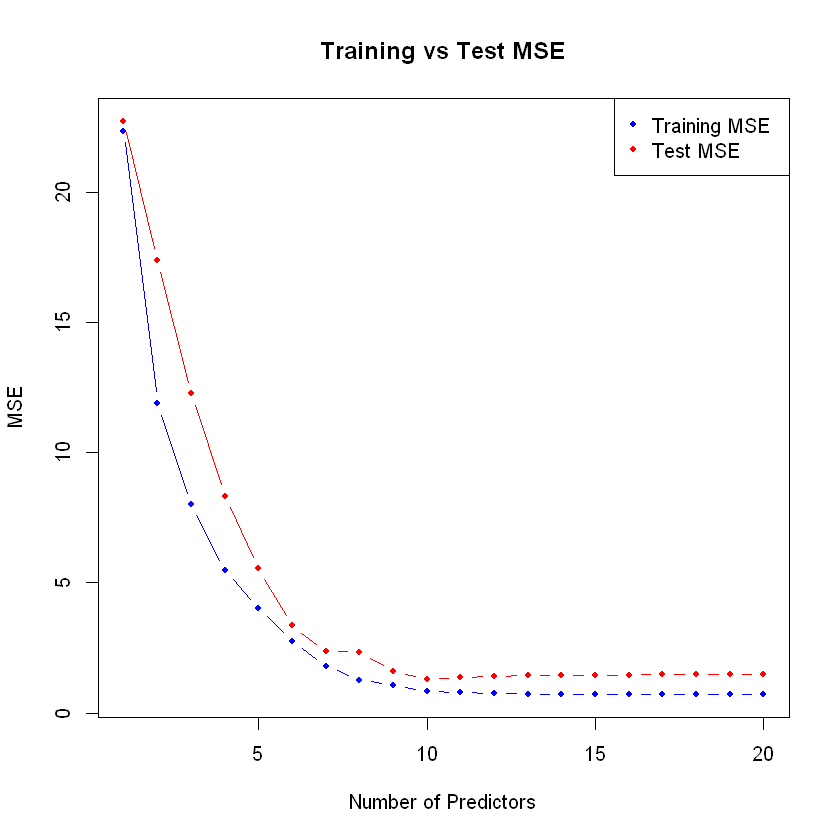

In [29]:
library(leaps)

# Best subset selection on training data
regfit_full <- regsubsets(y ~ ., data = train, nvmax = 20)
reg_summary <- summary(regfit_full)

# Function to get predictions from regsubsets (it doesn't have a built-in predict)
predict.regsubsets <- function(object, newdata, id) {
  form  <- as.formula(object$call[[2]])
  mat   <- model.matrix(form, newdata)
  coefi <- coef(object, id = id)
  mat[, names(coefi)] %*% coefi
}

# Calculate training and test MSE for each model size
train_mse <- rep(NA, 20)
test_mse  <- rep(NA, 20)

for (i in 1:20) {
  # Training MSE
  pred_train    <- predict.regsubsets(regfit_full, train, id = i)
  train_mse[i]  <- mean((train$y - pred_train)^2)
  
  # Test MSE
  pred_test    <- predict.regsubsets(regfit_full, test, id = i)
  test_mse[i]  <- mean((test$y - pred_test)^2)
}

# Plot
plot(1:20, train_mse, type = "b", col = "blue", pch = 20,
     xlab = "Number of Predictors", ylab = "MSE",
     main = "Training vs Test MSE", ylim = range(c(train_mse, test_mse)))
lines(1:20, test_mse, type = "b", col = "red", pch = 20)
legend("topright", legend = c("Training MSE", "Test MSE"),
       col = c("blue", "red"), pch = 20)
cat("Best model by test MSE:", which.min(test_mse), "predictors\n")

c) Identify the best model according the test MSE. How does this model compare to the actual model used to simulate the dataset?

*Note: If the model identified contains only an intercept or all of the features, then generate a new dataset (i.e. repeat part a with a different random seed) until the test set MSE is minimized for an intermediate model size.*

In [31]:
best_size <- which.min(test_mse)
cat("Best model size:", best_size, "predictors\n\n")
coef(regfit_full, best_size)

Best model size: 10 predictors



(Intercept)         X.1         X.2         X.3         X.4         X.5 
 0.09902108  1.42071727 -2.01120946  3.09239124  0.46263178 -0.67691481 
       X.11        X.12        X.15        X.18        X.20 
 1.85904613 -0.67926356  1.09816121 -1.19498778  2.31462826

> The best model by test MSE selected the 10 predictors matching the betas. The model correctly identified the predictors and estimated coefficients close to the true values and so the model was aable to model well with the true structure of the data.

**DUE:** 5pm EST, April 2, 2026

**IMPORTANT** Did you collaborate with anyone on this assignment? If so, list their names here.
> *Someone's Name*